In [1]:
import pickle as pkl
import random
import numpy as np
import os

In [2]:
# Data processing and analysis
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.preprocessing import StandardScaler

# Visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Dimensionality reduction and clustering
import umap
import scanpy as sc
import anndata as ad
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx

# GO analysis
from goatools.obo_parser import GODag
from goatools.associations import read_gaf
import gseapy as gp

# Utilities
import itertools
from collections import defaultdict
import tqdm
import math

/home/guoyu/SLformer_interpretation/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/guoyu/SLformer_interpretation/.venv/lib/python3.10/site-packages/goatools/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [3]:
with open("/home/jienihu/sc/SLformer/data/saved_data/map/gene2id.pkl", 'rb') as f: 
    gene2id_map = pkl.load(f)
with open("/home/jienihu/sc/SLformer/data/saved_data/map/cancer_list.txt") as f:
    cancer_list = [line.rstrip('\n') for line in f]
cancer_list

['KIRC', 'COAD', 'LAML', 'OV', 'BRCA', 'CESC', 'SKCM', 'LUAD', 'Glioma']

In [4]:
id2gene_map = {i:g for g,i in gene2id_map.items()}
id2cancer_map = {i:cancer for i,cancer in enumerate(cancer_list)}
cancer2id_map = {cancer:i for i,cancer in enumerate(cancer_list)}

In [5]:
res_dir = "/home/jienihu/sc/SLformer/experiment/inference/all_SL"
name = "mix_slformer_kg"
SEED = 42
np.random.seed(SEED)

In [6]:
geneformer_path = 'data/saved_data/map/geneformer_emb.pkl'
with open(geneformer_path, 'rb') as f:
        geneformer_emb = pkl.load(f)

In [7]:
def get_emb(name, cancer=None):
    with open(os.path.join(res_dir, f"{name}_transformeremb.pkl"), 'rb') as f: 
        emb = pkl.load(f)
    
    
    
    if emb[0][0].ndim == 2:
        print(emb[0][0].shape)
        emb_gene1 = [emb[i][0] for i in range(5)]
        emb_gene2 = [emb[i][1] for i in range(5)]
    else:
        print(emb[0][0].shape)
        emb_gene1 = [emb[i][0][:,0,:] for i in range(5)]
        emb_gene2 = [emb[i][1][:,0,:] for i in range(5)]
    emb1_cat = np.concatenate(emb_gene1, axis=0)
    emb2_cat = np.concatenate(emb_gene2, axis=0)
    emb_total = np.concatenate([emb1_cat, emb2_cat], axis=0)

    df_all = [pd.read_csv(os.path.join(res_dir, f"pred_{name}_cv{cv}.csv")) for cv in range(1,6)]
    context_cat = pd.concat([df['cancer'] for df in df_all]).tolist()*2
    gene1_cat = pd.concat([df['primary_gene'] for df in df_all]).tolist()
    gene2_cat = pd.concat([df['partner_gene'] for df in df_all]).tolist()
    gene_total = gene1_cat+gene2_cat
    
    # Average embeddings for duplicate (gene, context) entries
    df = pd.DataFrame({
        'gene': gene_total,
        'context': context_cat,
        'embedding': list(emb_total)
    })

    avg_df = (
        df.groupby(['gene', 'context'])['embedding']
        .apply(lambda x: np.mean(np.stack(x), axis=0))
        .reset_index()
    )
    if cancer:
        avg_df = avg_df[avg_df['context'] == cancer]
        
    gene_unique = avg_df['gene'].tolist()
    context_unique = avg_df['context'].tolist()
    emb_unique = np.stack(avg_df['embedding'].tolist())

    
    return gene_unique, emb_unique, context_unique, avg_df

In [8]:
gene, emb, context, avg_df = get_emb(name)

(11727, 20, 512)


In [9]:
len(gene), emb.shape, len(context), avg_df.shape

(17691, (17691, 512), 17691, (17691, 3))

In [10]:
avg_df[avg_df['gene'] == 'BRCA1'].head()

,gene,context,embedding
1592,BRCA1,BRCA,"[-0.3741957, 1.1384085, -3.1114333, -0.7576399..."
1593,BRCA1,CESC,"[0.28219655, 0.59818214, -2.9052937, -0.618560..."
1594,BRCA1,COAD,"[0.3069665, 0.039774433, -2.8322031, -0.942782..."
1595,BRCA1,KIRC,"[0.4208322, 0.38323197, -2.1915824, -1.1399584..."
1596,BRCA1,LUAD,"[-0.46176636, 0.60485643, -3.3891938, -0.99840..."


In [11]:
avg_df[avg_df['gene'] == 'PARP1'].head()

,gene,context,embedding
10388,PARP1,BRCA,"[-0.4792456, 1.1717535, 2.58808, -2.0465028, 0..."
10389,PARP1,CESC,"[-0.32621622, 0.0008096853, 2.5434742, -1.4204..."
10390,PARP1,COAD,"[-0.48415977, 0.84052426, 3.0267842, -1.632938..."
10391,PARP1,KIRC,"[-0.2942486, -0.1420069, 2.7290077, -1.3796275..."
10392,PARP1,LAML,"[-0.121511616, 0.7029349, 2.7536516, -1.741683..."


In [12]:
def cos_sim(A,B):
    dot_product = np.dot(A, B)
    norm_A = np.linalg.norm(A)
    norm_B = np.linalg.norm(B)
    return dot_product / (norm_A * norm_B)


def calc_sim_same_gene(gene, emb, context, n_sample=-1, use_geneformer=False):
    """
    Calculate cosine similarity for the same gene across different cancer contexts.
    
    Args:
        gene: List of gene names
        emb: Embeddings array (ignored if use_geneformer=True)
        context: List of cancer contexts
        n_sample: Number of top genes to sample (-1 for all)
        use_geneformer: If True, use geneformer embeddings instead
    """
    if use_geneformer:
        with open("/home/jienihu/sc/SLformer/data/saved_data/map/geneformer_emb.pkl", 'rb') as f: 
            geneformer_emb = pkl.load(f)
        
        gene_context_df = pd.DataFrame({"gene": gene, "context": context})
        gene_selected = gene_context_df['gene'].value_counts().index[:n_sample]
        cos_sim_all = []
        
        try:
            for g in gene_selected:
                g_idx = gene2id_map[g]
                for i in range(8):
                    for j in range(i+1,8):
                        cos_sim_all.append({
                            'gene': g,
                            'cancer1': id2cancer_map[i],
                            'cancer2': id2cancer_map[j],
                            'cos_sim': cos_sim(geneformer_emb[i][g_idx], geneformer_emb[j][g_idx])
                        })
        except:
            print(f"not found gene in geneformer embeddings")
        
        return gene_selected, pd.DataFrame(cos_sim_all)
    
    else:
        gene_context_df = pd.DataFrame({"gene": gene, "context": context})
        gene_selected = gene_context_df['gene'].value_counts().index[:n_sample]
        
        cos_sim_all = []
        
        for g in gene_selected:
            gene_df = gene_context_df[gene_context_df['gene']==g]
            idx = gene_df.index
            for i in range(len(gene_df)):
                for j in range(i+1, len(gene_df)):
                    cos_sim_all.append({
                        'gene': g,
                        'cancer1': gene_df['context'][idx[i]],
                        'cancer2': gene_df['context'][idx[j]],
                        'cos_sim': cos_sim(emb[idx[i]], emb[idx[j]])
                    })

        return gene_selected, pd.DataFrame(cos_sim_all)

In [13]:
gene_selected, cos_sim_all_kg = calc_sim_same_gene(gene, emb, context)

In [14]:
cos_sim_all_kg.shape

(8108, 4)

In [15]:
cos_sim_all_kg.head()

,gene,cancer1,cancer2,cos_sim
0,PARP1,BRCA,CESC,0.876984
1,PARP1,BRCA,COAD,0.858585
2,PARP1,BRCA,KIRC,0.725539
3,PARP1,BRCA,LAML,0.887984
4,PARP1,BRCA,LUAD,0.884282


## functional similarity

In [16]:
go_dag = GODag("/home/jienihu/sc/SLformer/data/GO/go-basic.obo")
annotations = read_gaf("/home/jienihu/sc/SLformer/data/GO/goa_human.gaf", go_dag=go_dag)

/home/jienihu/sc/SLformer/data/GO/go-basic.obo: fmt(1.2) rel(2024-06-17) 45,494 Terms
HMS:0:00:18.411179 707,170 annotations READ: /home/jienihu/sc/SLformer/data/GO/goa_human.gaf 
36129 IDs in loaded association branch, BP


In [17]:
id_mapping = pd.read_csv("/home/jienihu/sc/SLformer/data/GO/idmapping_2024_11_09.tsv", sep='\t')
id_mapping = dict(zip(id_mapping['From'], id_mapping['To']))

In [18]:
anno_mapped = {}
for k, v in annotations.items():
    if k in id_mapping:
        anno_mapped[id_mapping[k]] = v

In [19]:
def find_shared_goterms(gene1, gene2, return_terms=False):

    go_terms_gene1 = {go_id for go_id in anno_mapped.get(gene1, [])}
    go_terms_gene2 = {go_id for go_id in anno_mapped.get(gene2, [])}

    shared_go_terms = go_terms_gene1.intersection(go_terms_gene2)

    if return_terms:
        return len(shared_go_terms), list(shared_go_terms)
    else:
        return len(shared_go_terms)


def pairs_shared_goterms(df):

    ngoterm_all = []

    for i in range(len(df)):
        gene1 = df['gene1'][i]
        gene2 = df['gene2'][i]
        nshared_go_terms = find_shared_goterms(gene1, gene2)
        ngoterm_all.append(nshared_go_terms)

    return ngoterm_all

In [20]:
def calc_sim_different_genes(gene, emb, context, n_sample=50, use_geneformer=False, df_pairs=None):
    """
    Calculate cosine similarity for different genes within the same cancer context.
    
    Args:
        gene: List of gene names
        emb: Embeddings array (ignored if use_geneformer=True)
        context: List of cancer contexts
        n_sample: Number of gene pairs to sample per cancer
        use_geneformer: If True, use geneformer embeddings instead
        df_pairs: Pre-existing DataFrame with gene pairs (for geneformer mode)
    """
    if use_geneformer:
        if df_pairs is None:
            raise ValueError("df_pairs is required when use_geneformer=True")
        
        with open("/home/jienihu/sc/SLformer/data/saved_data/map/geneformer_emb.pkl", 'rb') as f: 
            geneformer_emb = pkl.load(f)
        
        cos_sim_all = []

        for i, row in df_pairs.iterrows():
            try:
                cancer_idx = cancer2id_map[row['context']]
                g1_idx = gene2id_map[row['gene1']]
                g2_idx = gene2id_map[row['gene2']]
                cos_sim_all.append({
                    'gene1': row['gene1'],
                    'gene2': row['gene2'],
                    'context': row['context'],
                    'cos_sim': cos_sim(geneformer_emb[cancer_idx][g1_idx], geneformer_emb[cancer_idx][g2_idx])
                })
            except:
                print(f"not found genes")

        return pd.DataFrame(cos_sim_all)
    
    else:
        gene_context_df = pd.DataFrame({"gene": gene, "context": context})
        context_all = list(set(gene_context_df['context']))
        context_all.sort()
        cos_sim_all = []

        for cancer in context_all:
            df_cancer = gene_context_df[gene_context_df['context']==cancer]
            df_pairs = [df_cancer.sample(2, random_state=i, replace=False) for i in range(n_sample)]

            for pairs in df_pairs:
                idx = pairs.index
                cos_sim_all.append({
                    'gene1': pairs['gene'].iloc[0],
                    'gene2': pairs['gene'].iloc[1],
                    'context': cancer,
                    'cos_sim': cos_sim(emb[idx[0]], emb[idx[1]])
                })
            
        return pd.DataFrame(cos_sim_all)

In [21]:
cos_sim_all_kg = calc_sim_different_genes(gene, emb, context, n_sample=len(emb))  # 8 cancers, 5000 pairs per cancer
cos_sim_all_kg.head()

,gene1,gene2,context,cos_sim
0,BUB1,PTCH2,BRCA,0.139988
1,CDKN1C,TRA2B,BRCA,0.128705
2,LYN,MYLK,BRCA,0.193361
3,DNMT1,TMEM67,BRCA,0.129719
4,LY6K,SQLE,BRCA,0.167106


In [22]:
cos_sim_all_kg.describe()

,cos_sim
count,141528.000000
mean,0.191581
std,0.107480
min,-0.154621
25%,0.116607
50%,0.185224
75%,0.258933
max,0.762266


In [23]:
cos_sim_all_geneformer = calc_sim_different_genes(gene, emb, context, use_geneformer=True, df_pairs=cos_sim_all_kg)
cos_sim_all_geneformer.head()

,gene1,gene2,context,cos_sim
0,BUB1,PTCH2,BRCA,0.264478
1,CDKN1C,TRA2B,BRCA,0.163172
2,LYN,MYLK,BRCA,0.296313
3,DNMT1,TMEM67,BRCA,0.218975
4,LY6K,SQLE,BRCA,0.323455


In [24]:
cos_sim_all_geneformer.shape

(141528, 4)

In [25]:
cos_sim_all_geneformer['context'].value_counts()

context
BRCA    17691
CESC    17691
COAD    17691
KIRC    17691
LAML    17691
LUAD    17691
OV      17691
SKCM    17691
Name: count, dtype: int64

In [26]:
cos_sim_all_geneformer.describe()

,cos_sim
count,141528.000000
mean,0.192799
std,0.129950
min,-0.217538
25%,0.100414
50%,0.178636
75%,0.269935
max,0.837804


In [27]:
nshared_go_terms = pairs_shared_goterms(cos_sim_all_kg)

In [28]:
cos_sim_all_kg['nshared_go_terms'] = nshared_go_terms
cos_sim_all_geneformer['nshared_go_terms'] = nshared_go_terms

cos_sim_all_kg = cos_sim_all_kg.sort_values(by='nshared_go_terms', ascending=False)
cos_sim_all_geneformer = cos_sim_all_geneformer.sort_values(by='nshared_go_terms', ascending=False)

In [29]:
cos_sim_all_kg = cos_sim_all_kg.drop_duplicates(keep='first')
cos_sim_all_geneformer = cos_sim_all_geneformer.drop_duplicates(keep='first')

In [54]:
def plot_func_sim_allcancer(df, title, go_thr=3):

    plt.figure(figsize=(14, 6), dpi=300)
    
    df_high = df[df['nshared_go_terms']>=go_thr][:300]
    df_low = df[df['nshared_go_terms']<go_thr]
    
    print(df_high.shape, df_low.shape)
    df_low = df_low.sample(n=len(df_high), random_state=SEED)
    

    sns.kdeplot(df_high['cos_sim'], fill=True, linewidth=2, label='gene pairs with similar functions', color='#1CE17F')
    sns.kdeplot(df_low['cos_sim'], fill=True, linewidth=2, label='gene pairs with dissimilar functions', color='#FA512F')

    # plt.title(title, fontsize=15)
    plt.xlabel('Cosine Similarity of pairs of gene embeddings in the same cancer', fontsize=18)
    plt.ylabel('Density', fontsize=18)
    plt.legend(fontsize=14)
    plt.title(title, fontsize=18)
    plt.show()

(300, 5) (96688, 5)


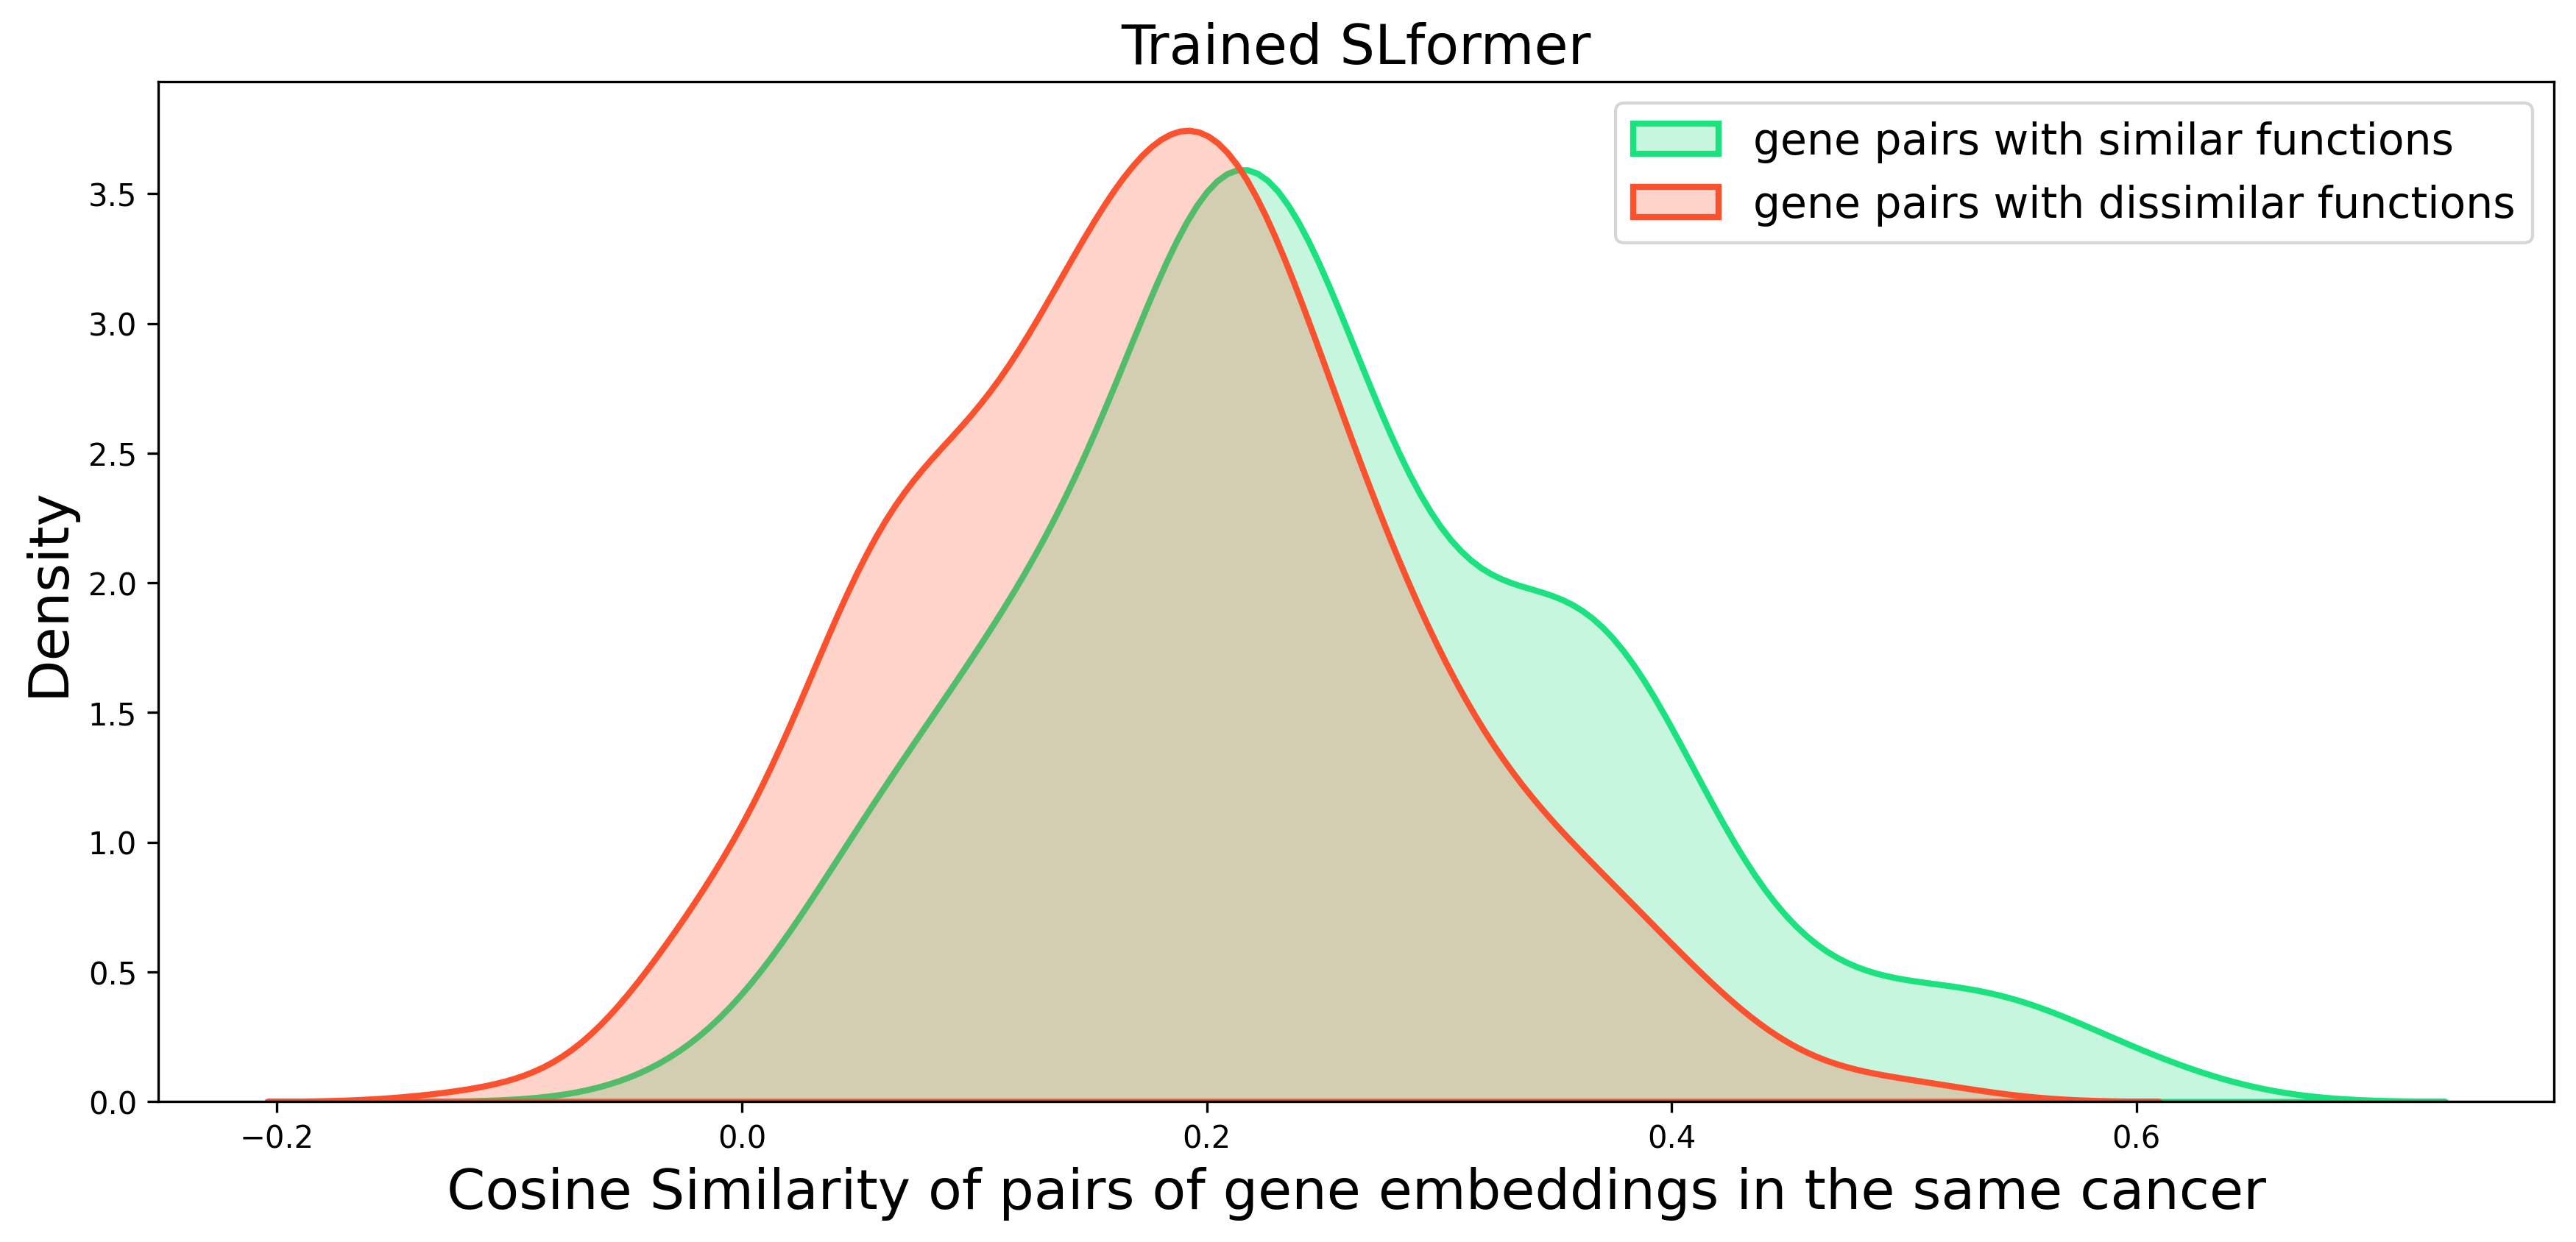

In [55]:
GO_THR = 3
plot_func_sim_allcancer(cos_sim_all_kg, title="Trained SLformer", go_thr=GO_THR)

(300, 5) (96688, 5)


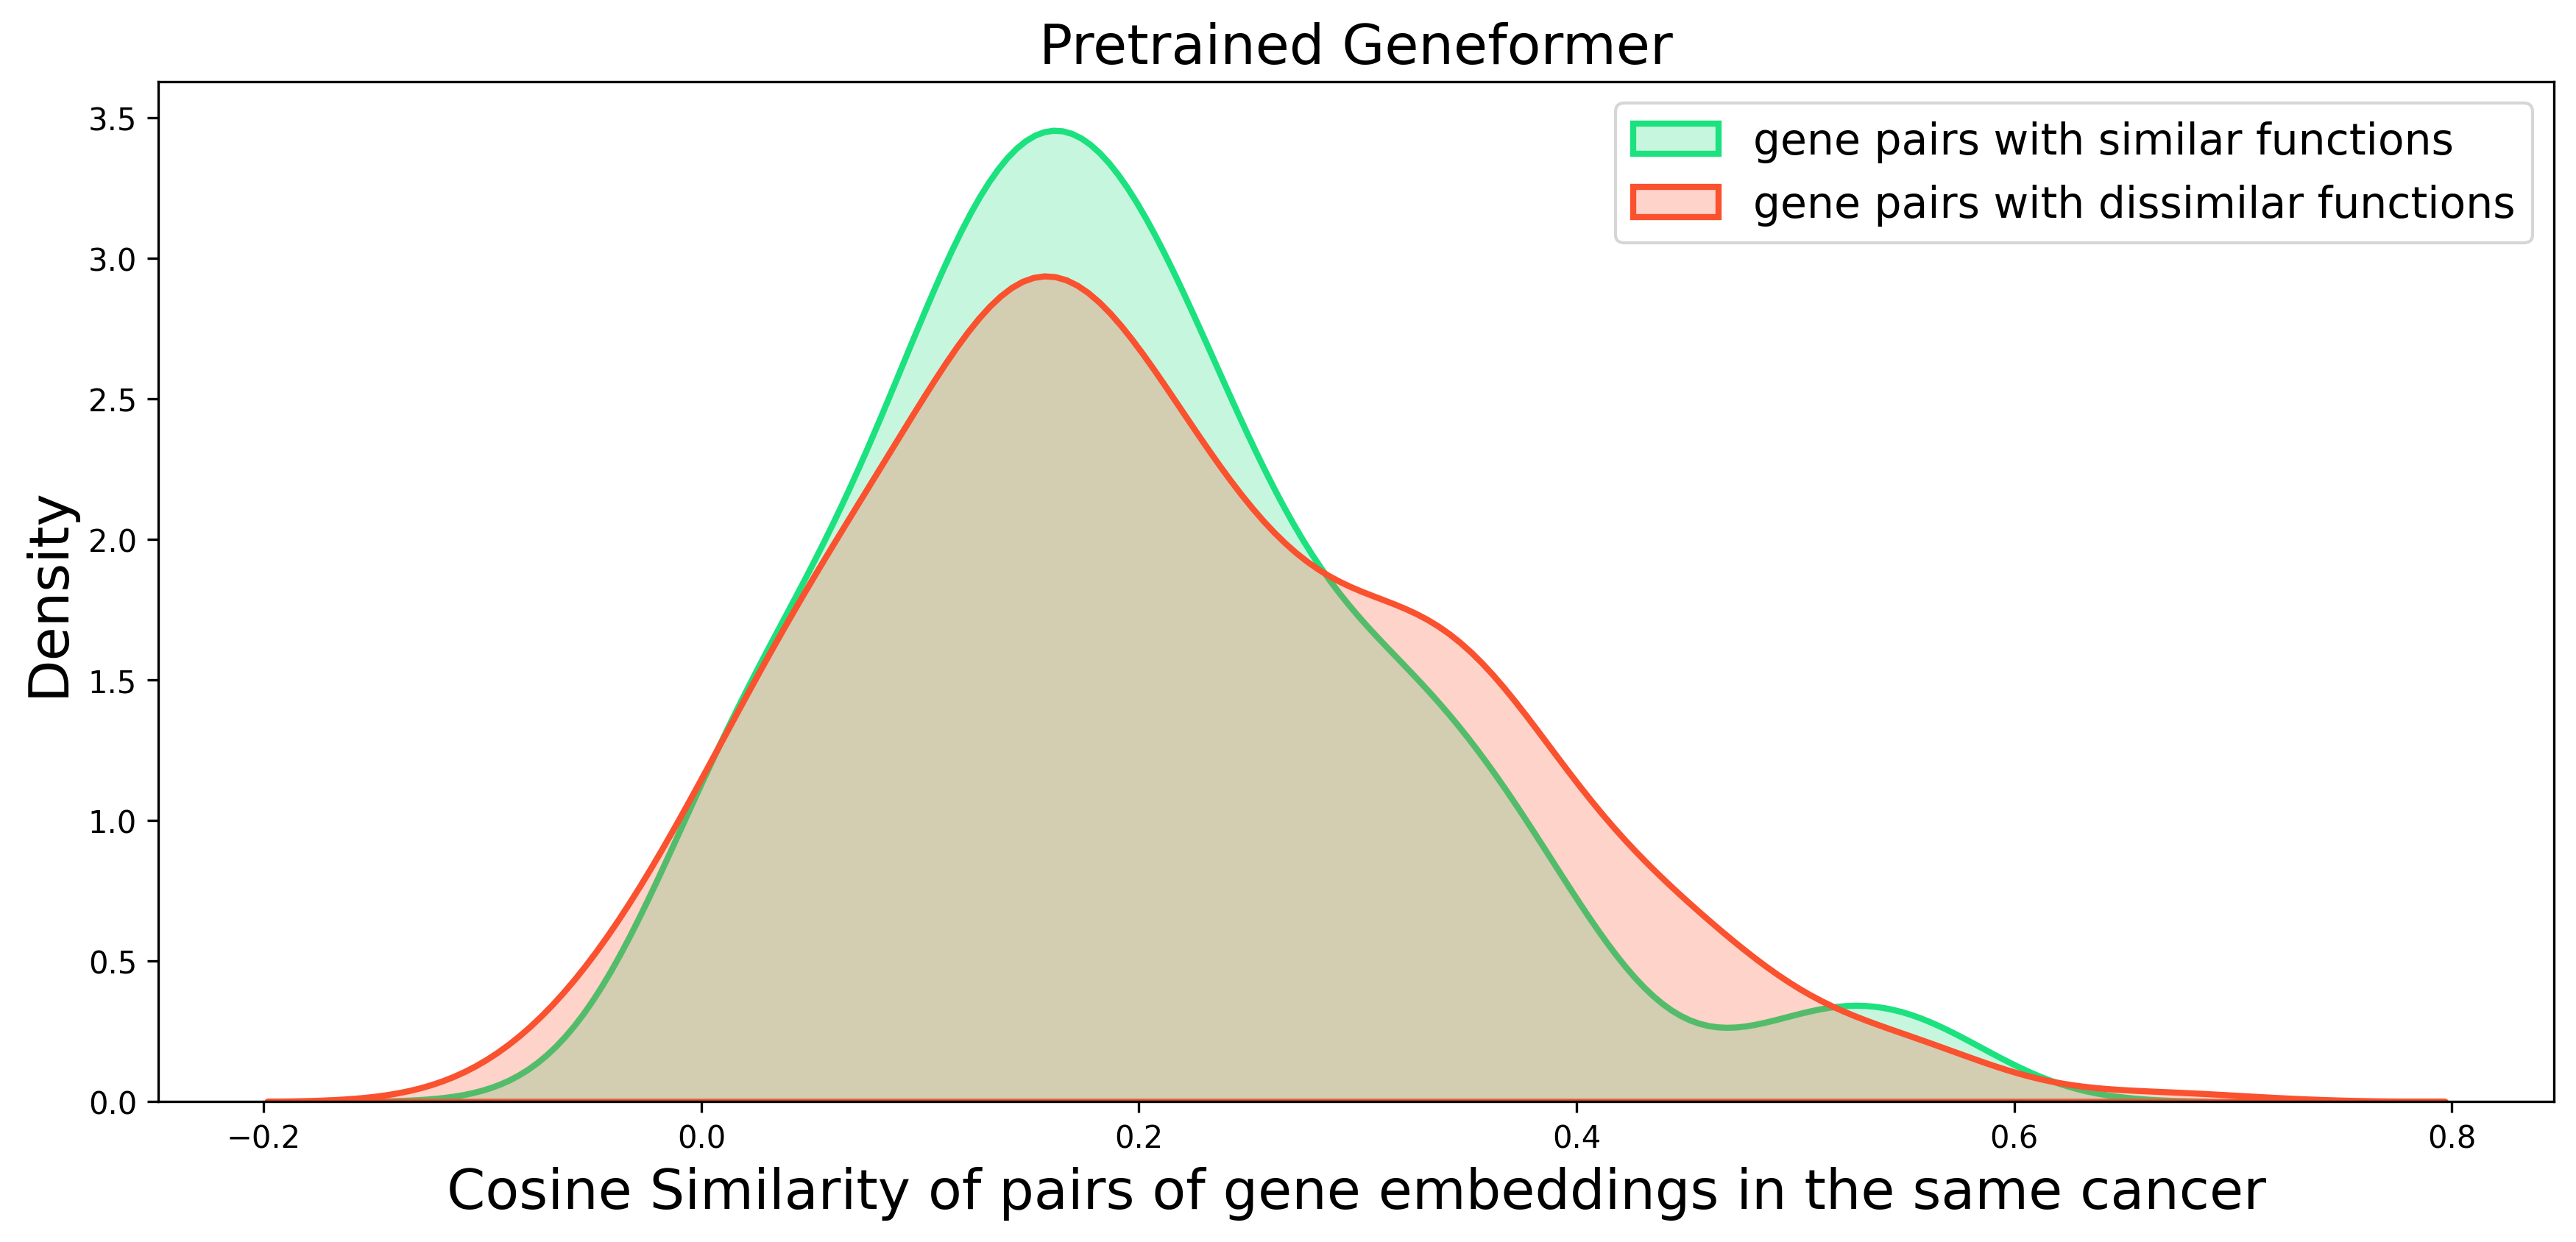

In [56]:
plot_func_sim_allcancer(cos_sim_all_geneformer, title="Pretrained Geneformer", go_thr=GO_THR)

## Function & Embeddings

### Function similarity

In [33]:
def build_gene_adata(gene, emb, context, cancer_type):
    """
    Create AnnData object for gene embeddings from a specific cancer context.
    """
    gene = np.array(gene)
    emb = np.array(emb)
    context = np.array(context)

    mask = context == cancer_type
    emb_cancer = emb[mask]
    gene_cancer = gene[mask]

    adata = ad.AnnData(X=emb_cancer)
    adata.obs['gene'] = gene_cancer
    adata.obs['context'] = cancer_type

    return adata

def run_louvain_clustering(adata, resolution=2.0):
    """
    Run Louvain clustering on the gene-level embeddings.
    """
    sc.pp.neighbors(adata, n_neighbors=15, use_rep="X")
    sc.tl.leiden(adata, resolution=resolution, key_added='gene_cluster')
    return adata

def improved_clustering_analysis(gene, emb, context, cancer_name):
    """
    Multi-resolution clustering with stability analysis
    """
    adata = build_gene_adata(gene, emb, context, cancer_name)
    
    resolutions = np.logspace(np.log10(0.5), np.log10(5), 50)
    resolutions = np.round(resolutions, 2)
    stability_scores = []
    
    for res in resolutions:
        adata_temp = adata.copy()
        adata_temp = run_louvain_clustering(adata_temp, resolution=res)
        
        try:
            # Use Calinski-Harabasz index instead of modularity
            # This measures the ratio of between-cluster dispersion to within-cluster dispersion
            from sklearn.metrics import calinski_harabasz_score
            
            # Convert cluster labels to numeric
            cluster_labels = adata_temp.obs['gene_cluster'].astype('category').cat.codes
            
            # Calculate CH index (higher is better)
            ch_score = calinski_harabasz_score(adata_temp.X, cluster_labels)
            stability_scores.append(ch_score)
            
        except Exception as e:
            print(f"Error calculating CH score for resolution {res}: {e}")
            # Fallback to number of clusters (penalize too many or too few clusters)
            n_clusters = len(adata_temp.obs['gene_cluster'].unique())
            n_samples = adata_temp.n_obs
            # Optimal cluster range heuristic: sqrt(n/2) to n/10
            optimal_range = (np.sqrt(n_samples/2), n_samples/10)
            if optimal_range[0] <= n_clusters <= optimal_range[1]:
                stability_scores.append(n_clusters)
            else:
                stability_scores.append(0)  # Penalize bad cluster counts
    
    # Choose optimal resolution
    optimal_res = resolutions[np.argmax(stability_scores)]
    print(f"Optimal resolution: {optimal_res} (CH score: {max(stability_scores):.3f})")
    
    return run_louvain_clustering(adata, resolution=optimal_res)

def get_metagenes(adata, min_genes=5):
    """
    Retrieve gene clusters with >= min_genes genes.
    """
    clusters = adata.obs['gene_cluster'].unique()
    metagenes = {}
    for cluster in clusters:
        genes = adata.obs.loc[adata.obs['gene_cluster'] == cluster, 'gene'].tolist()
        if len(genes) >= min_genes:
            metagenes[str(cluster)] = genes
    return metagenes

In [34]:
cancer_name = "BRCA"
# adata = build_gene_adata(gene, emb, context, cancer_name)
adata = improved_clustering_analysis(gene, emb, context, cancer_name)
metagenes = get_metagenes(adata)

/tmp/ipykernel_4011232/1491178577.py:24: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=resolution, key_added='gene_cluster')


Optimal resolution: 0.6 (CH score: 11.129)


In [35]:
for cluster_id, genes in metagenes.items():
    print(f"Metagene {cluster_id}: {len(genes)} genes")

Metagene 3: 54 genes
Metagene 0: 169 genes
Metagene 2: 62 genes
Metagene 1: 70 genes
Metagene 4: 18 genes


In [36]:
def plot_similarity_networks_subplots(metagenes, emb_dict, cancer_name, threshold=0.4, max_genes=100):
    """
    Plot cosine similarity networks for each metagene as subplots.
    """
    n_clusters = len(metagenes)
    ncols = 2
    nrows = math.ceil(n_clusters / ncols)

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10 * ncols, 8 * nrows))
    axs = axs.flatten()

    for i, (cluster_id, genes) in enumerate(metagenes.items()):
        ax = axs[i]

        # Limit number of genes for readability
        genes = [g for g in genes if g in emb_dict]
        if len(genes) > max_genes:
            genes = genes[:max_genes]

        vectors = [emb_dict[g] for g in genes]
        sim_matrix = cosine_similarity(vectors)
        names = genes

        edges = []
        for m in range(len(names)):
            for n in range(m + 1, len(names)):
                sim = sim_matrix[m][n]
                if sim > threshold:
                    edges.append((names[m], names[n], round(sim, 2)))

        G = nx.Graph()
        G.add_weighted_edges_from(edges)

        pos = nx.spring_layout(G, k=0.4, iterations=15, seed=SEED)
        edge_widths = [d['weight'] * 10 for u, v, d in G.edges(data=True)]

        nx.draw(G, pos, ax=ax,
                with_labels=True,
                node_size=500,
                edge_color='lightblue',
                width=edge_widths,
                font_size=8)
        edge_labels = nx.get_edge_attributes(G, "weight")
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6, ax=ax)

        ax.set_title(f"Cancer: {cancer_name} - Cluster {cluster_id} ({len(genes)} genes)")
        ax.axis("off")

    # Hide unused subplots
    for j in range(i + 1, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()

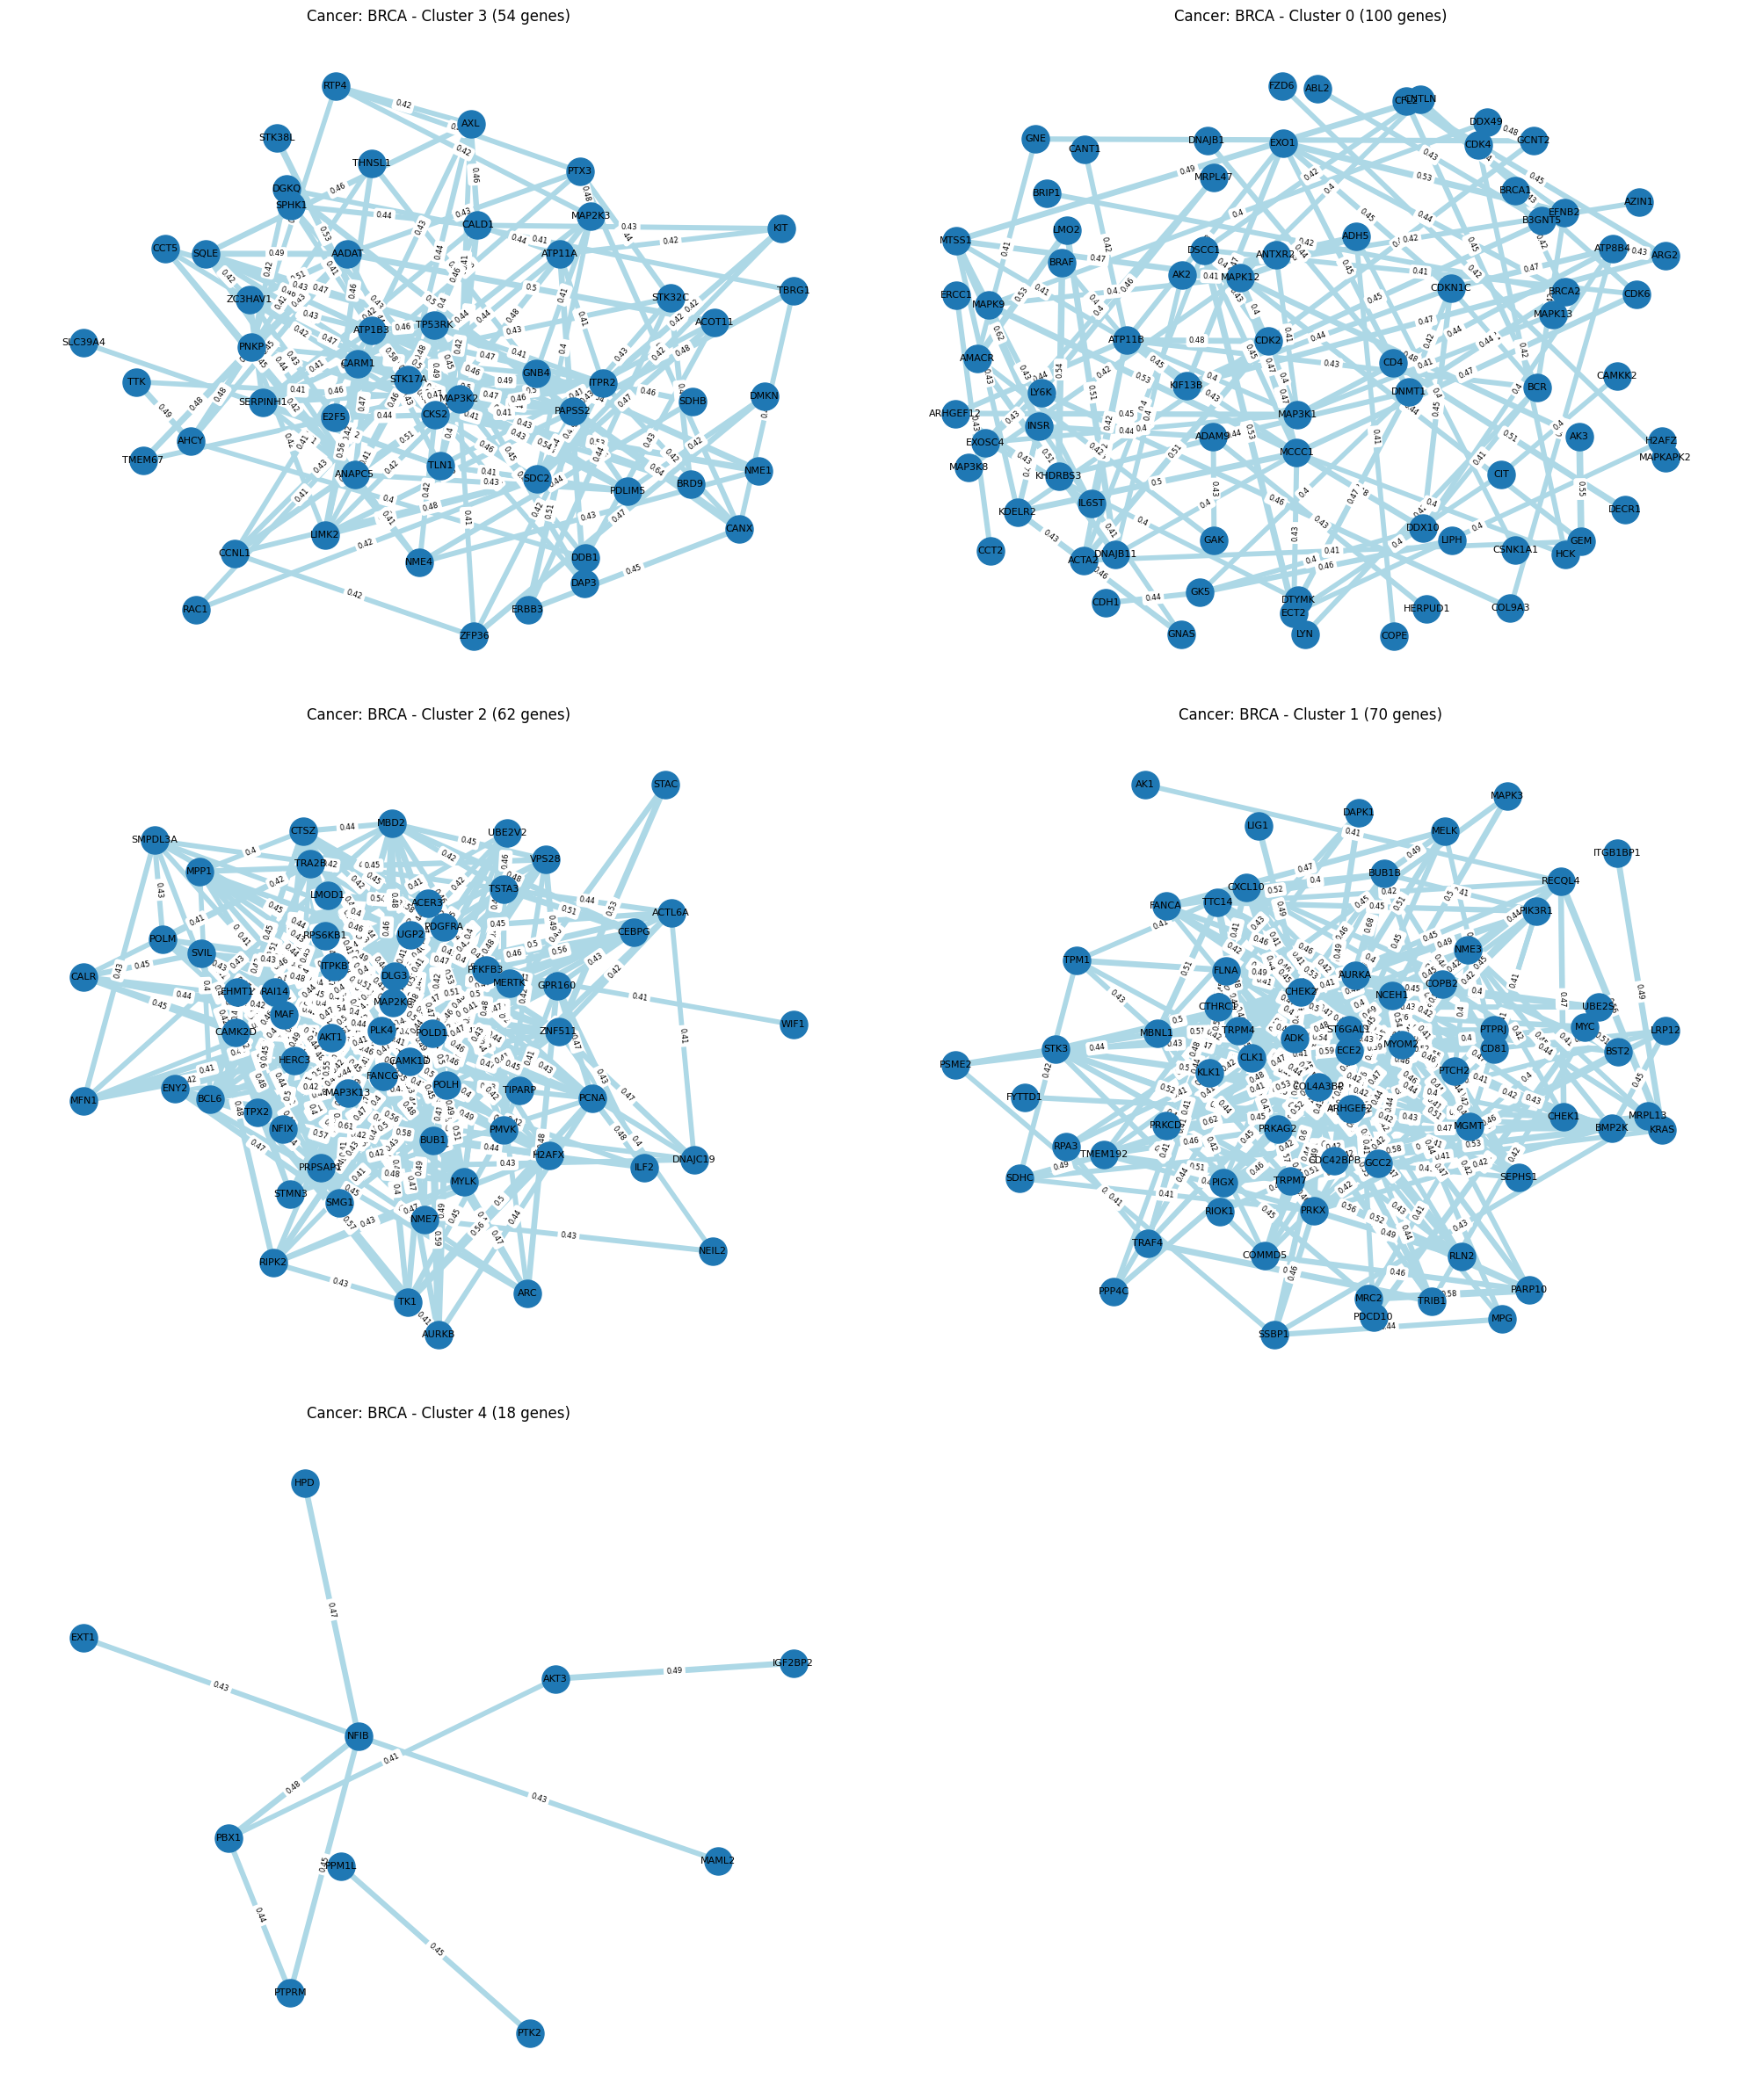

In [37]:
emb_dict = {g: vec for g, vec in zip(adata.obs['gene'], adata.X)}
plot_similarity_networks_subplots(metagenes, emb_dict, cancer_name, threshold=0.4)

In [38]:
gene_pool = set()
for gene_list in metagenes.values():
    gene_pool.update(gene_list)
gene_pool = list(gene_pool)
gene_pool = [g for g in gene_pool if g in anno_mapped]

def analyze_go_similarity_in_metagenes(metagenes, anno_mapped, min_shared_threshold=3):
    """
    For each gene cluster, compute number of shared GO terms per gene pair,
    and count how many exceed a threshold (e.g., ≥3 shared GO terms).
    """
    all_results = []
    summary = []

    for cluster_id, genes in metagenes.items():
        gene_pairs = list(itertools.combinations(genes, 2))
        cluster_data = []

        for g1, g2 in gene_pairs:
            shared_go_count, shared_go_list = find_shared_goterms(g1, g2, return_terms=True)
            cluster_data.append({
                'cluster': cluster_id,
                'gene1': g1,
                'gene2': g2,
                'n_shared': shared_go_count,
                'shared_terms': shared_go_list
            })

        df_cluster = pd.DataFrame(cluster_data)
        high_shared_count = (df_cluster['n_shared'] >= min_shared_threshold).sum()
        avg_shared = df_cluster['n_shared'].mean()
        # background
        sampled_pairs = random.sample(list(itertools.combinations(gene_pool, 2)), len(gene_pairs))
        backgound_avg_shared = np.mean([find_shared_goterms(g1, g2) for g1, g2 in sampled_pairs])

        summary.append({
            'cluster': cluster_id,
            'num_genes': len(genes),
            'num_pairs': len(gene_pairs),
            'high_shared_pairs': high_shared_count,
            'avg_shared_terms': avg_shared,
            'background_avg_shared_terms': backgound_avg_shared
        })

        all_results.append(df_cluster)

    df_all_pairs = pd.concat(all_results, ignore_index=True)
    df_summary = pd.DataFrame(summary)

    return df_all_pairs, df_summary


def compute_background_shared_go(num_samples=5000):
    """
    Sample random gene pairs from the full gene set and compute shared GO terms.
    """
    sampled_pairs = random.sample(list(itertools.combinations(gene_pool, 2)), num_samples)

    results = []
    for g1, g2 in sampled_pairs:
        shared_go_count, shared_go_list = find_shared_goterms(g1, g2, return_terms=True)
        results.append({
            'gene1': g1,
            'gene2': g2,
            'n_shared': shared_go_count,
            'shared_terms': shared_go_list
        })

    df_background = pd.DataFrame(results)
    return df_background

In [39]:
# Analyze GO similarity in metagenes
df_all, df_summary = analyze_go_similarity_in_metagenes(metagenes, anno_mapped, min_shared_threshold=3)
df_background = compute_background_shared_go(num_samples=5000)

print("Summary of GO term sharing per cluster:")
df_summary_sorted = df_summary.sort_values(by='avg_shared_terms', ascending=False)
print(df_summary_sorted)

print(f"Background avg shared GO terms: {df_background['n_shared'].mean():.3f}")

# Save detailed results for analysis or plotting
df_all.to_csv("go_term_pairwise_details.csv", index=False)
df_summary.to_csv("go_term_cluster_summary.csv", index=False)

Summary of GO term sharing per cluster:
  cluster  num_genes  num_pairs  high_shared_pairs  avg_shared_terms  \
4       4         18        153                  3          0.267974   
1       0        169      14196                228          0.210341   
2       2         62       1891                 28          0.193020   
3       1         70       2415                 38          0.183851   
0       3         54       1431                 15          0.141859   

   background_avg_shared_terms  
4                     0.228758  
1                     0.208932  
2                     0.215230  
3                     0.216563  
0                     0.190776  
Background avg shared GO terms: 0.209


In [40]:
df_all[df_all['n_shared'] >= 3].sort_values(by='n_shared', ascending=False)

,cluster,gene1,gene2,n_shared,shared_terms
11080,0,HCK,LYN,9,"[GO:0002862, GO:0046777, GO:0006468, GO:000716..."
10240,0,GATA3,RB1,9,"[GO:2000679, GO:0045892, GO:0006338, GO:000012..."
6174,0,CDK4,CDK6,8,"[GO:0000082, GO:0051726, GO:0010389, GO:000646..."
11629,0,INSR,LYN,8,"[GO:0046777, GO:0006468, GO:0030335, GO:000716..."
315,3,AXL,ERBB3,8,"[GO:0051897, GO:0007275, GO:0007169, GO:000716..."
...,...,...,...,...,...
18182,1,CHEK2,MELK,3,"[GO:0046777, GO:0000086, GO:0006468]"
18197,1,CHEK2,PRKCD,3,"[GO:0006974, GO:0050821, GO:0006468]"
18520,1,CXCL10,MYC,3,"[GO:0008284, GO:0010332, GO:0045944]"
18565,1,DAPK1,MAPK3,3,"[GO:0035556, GO:0006915, GO:0006468]"


#### Pathway enrichment
clusters whose avg shared goterms > background

In [41]:
df_database = pd.DataFrame([
    ['GO_Biological_Process_2021', 6036],
    ['GO_Molecular_Function_2021', 1274],
    ['Reactome_2022', 1818],
    ['KEGG_2021_Human', 332]
], columns=['dataset', 'term'])

In [42]:
databases = ['Reactome_2022']
m = df_database[df_database['dataset'].isin(databases)]['term'].sum()
p_thresh = 0.05 / m  # Bonferroni correction
p_thresh

np.float64(2.7502750275027505e-05)

In [43]:
selected_cluster = '4'  
gene_list = metagenes[selected_cluster]
print(len(gene_list), gene_list)

18 ['AKT3', 'CD3E', 'COL1A1', 'EXT1', 'FBN1', 'HPD', 'IGF2BP2', 'LGI4', 'MAML2', 'NFIB', 'PBX1', 'PPM1L', 'PTK2', 'PTPN13', 'PTPRM', 'RPL18A', 'RPL27', 'RPL35A']


In [44]:
enr_result = gp.enrichr(
    gene_list=gene_list,
    gene_sets=databases,
    organism='Human',
    outdir=f'./enr_results_cosine_{cancer_name}_cluster{selected_cluster}',
    cutoff=0.05,
)

result_df = enr_result.results
filtered_df = result_df[result_df['P-value'] < p_thresh]

filtered_df[['Term', 'P-value', 'Adjusted P-value', 'Genes']]

,Term,P-value,Adjusted P-value,Genes
0,Developmental Biology R-HSA-1266738,0.000002,0.000365,MAML2;RPL18A;LGI4;AKT3;RPL35A;RPL27;PBX1;PTK2
